# AI Blood Supply Command Center — Dataset Exploration & Analytics

Welcome to the exploratory analytics notebook for the **AI Blood Supply Command Center** prototype.
This notebook analyzes the **9 interconnected synthetic healthcare datasets** generated by the regional supply-chain simulation.

---
### Dataset Summary & Interconnection Architecture
- **hospitals.csv**: 30 synthetic facilities with bed, ICU, and blood storage capacities.
- **blood_banks.csv**: 10 regional hubs and district centers managing daily donor collections.
- **transport_network.csv**: Geographic road transit graph with travel times, traffic factors, and route disruptions.
- **donors.csv**: 5,000 synthetic non-PII donors with realistic blood groups and donation intervals.
- **events_context.csv**: 730 days of meteorological, seasonal, holiday, and disease outbreak context.
- **emergency_events.csv**: 390 emergency incidents (mass casualty, trauma surges, facility failures).
- **daily_demand.csv**: 175,200 historical demand records decomposed into surgery, trauma, and emergency needs.
- **inventory_batches.csv**: Cold-chain batch lifecycle (available, reserved, expired, transferred) with clinical shelf lives.
- **blood_requests.csv**: 260,000+ clinical requisition orders tracking fulfillment, delays, and shortages.


In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path("../data/raw")

# Load dataset summary
with open("../data/dataset_summary.json", "r") as f:
    summary = json.load(f)

print("DATASET SUMMARY OVERVIEW:")
for k, v in summary.items():
    if isinstance(v, (int, float)):
        print(f"  {k:<30}: {v:,}")
    elif isinstance(v, dict):
        print(f"  {k:<30}:")
        for sub_k, sub_v in v.items():
            if isinstance(sub_v, (int, float)):
                print(f"    - {sub_k:<28}: {sub_v:,}")
            else:
                print(f"    - {sub_k:<28}: {sub_v}")


DATASET SUMMARY OVERVIEW:
  number_of_hospitals           : 30
  number_of_blood_banks         : 10
  number_of_donors              : 5,000
  number_of_inventory_records   : 417,262
  number_of_demand_records      : 175,200
  number_of_requests            : 260,660
  number_of_emergency_events    : 390
  number_of_shortages           : 27,318
  number_of_transfers           : 35,262
  number_of_expired_units       : 41,714
  metrics                       :
    - total_requests              : 260,660
    - fulfilled_immediately       : 230,216
    - fulfilled_delayed           : 3,126
    - partially_fulfilled         : 8,531
    - unfulfilled                 : 18,787
    - overall_fulfillment_rate_pct: 89.52
    - immediate_fulfillment_rate_pct: 88.32
    - shortage_rate_pct           : 10.48
    - expiry_rate_pct             : 4.46
  simulation_metadata           :
    - years                       : 2
    - simulation_days             : 730
    - start_date                  : 2024-01

In [2]:
# Load all 9 datasets
hospitals_df = pd.read_csv(DATA_DIR / "hospitals.csv")
blood_banks_df = pd.read_csv(DATA_DIR / "blood_banks.csv")
transport_df = pd.read_csv(DATA_DIR / "transport_network.csv")
donors_df = pd.read_csv(DATA_DIR / "donors.csv")
context_df = pd.read_csv(DATA_DIR / "events_context.csv")
emergency_df = pd.read_csv(DATA_DIR / "emergency_events.csv")
demand_df = pd.read_csv(DATA_DIR / "daily_demand.csv")
inventory_df = pd.read_csv(DATA_DIR / "inventory_batches.csv")
requests_df = pd.read_csv(DATA_DIR / "blood_requests.csv")

print("All 9 datasets loaded successfully!")


All 9 datasets loaded successfully!


## 1. Blood Group Distribution: Donors vs Demand
Comparing the distribution of blood groups in the donor population against clinical demand.
Notice how high-prevalence blood groups ($O^+, A^+, B^+$) form the bulk of demand, while universal donor $O^-$ is disproportionately critical in emergencies.


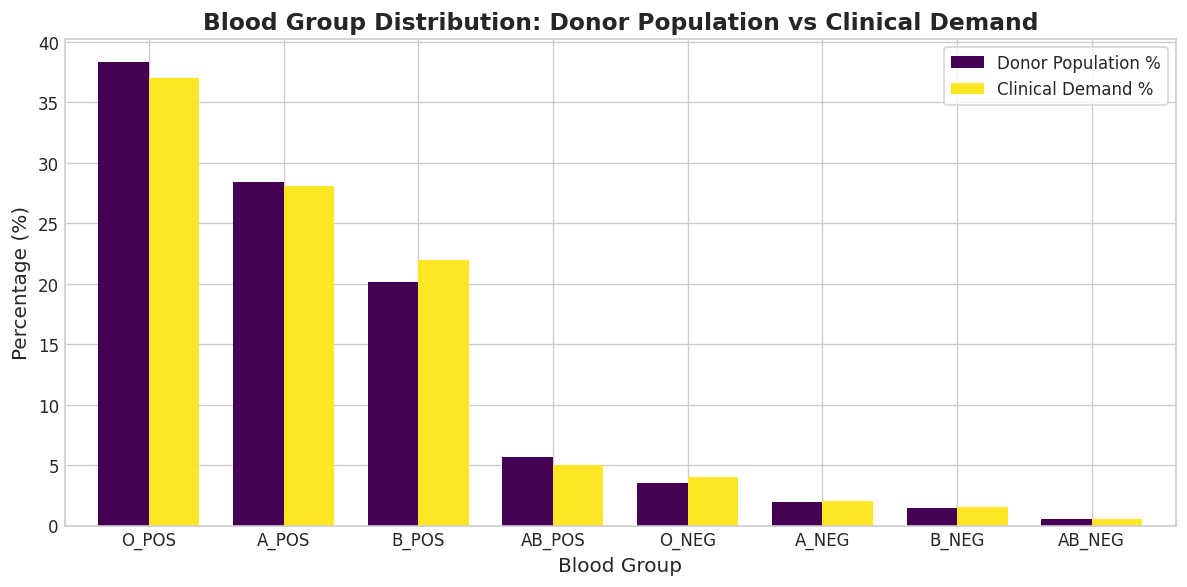

In [3]:
donor_bg_pct = (donors_df['blood_group'].value_counts(normalize=True) * 100).rename('Donor Population %')
demand_bg_pct = (demand_df.groupby('blood_group')['units_used'].sum() / demand_df['units_used'].sum() * 100).rename('Clinical Demand %')

bg_comp = pd.concat([donor_bg_pct, demand_bg_pct], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
bg_comp.plot(kind='bar', ax=ax, colormap='viridis', width=0.75)
ax.set_title('Blood Group Distribution: Donor Population vs Clinical Demand', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Blood Group', fontsize=12)
plt.xticks(rotation=0)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


## 2. Hospital Demand Distribution by Facility Type
Different hospital types serve distinct clinical roles:
- **Trauma Centers**: Highest daily demand driven by acute resuscitation and trauma surgery.
- **Teaching Hospitals**: High baseline volume across elective surgeries and complex cases.
- **General / Government**: Steady inpatient and maternal health requirements.
- **Specialty**: Specialized, scheduled elective care.


C:\Users\bhanu\AppData\Local\Temp\ipykernel_27996\73123348.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hosp_merged, x='hospital_type', y='avg_daily_demand', ax=ax1, palette='Spectral')


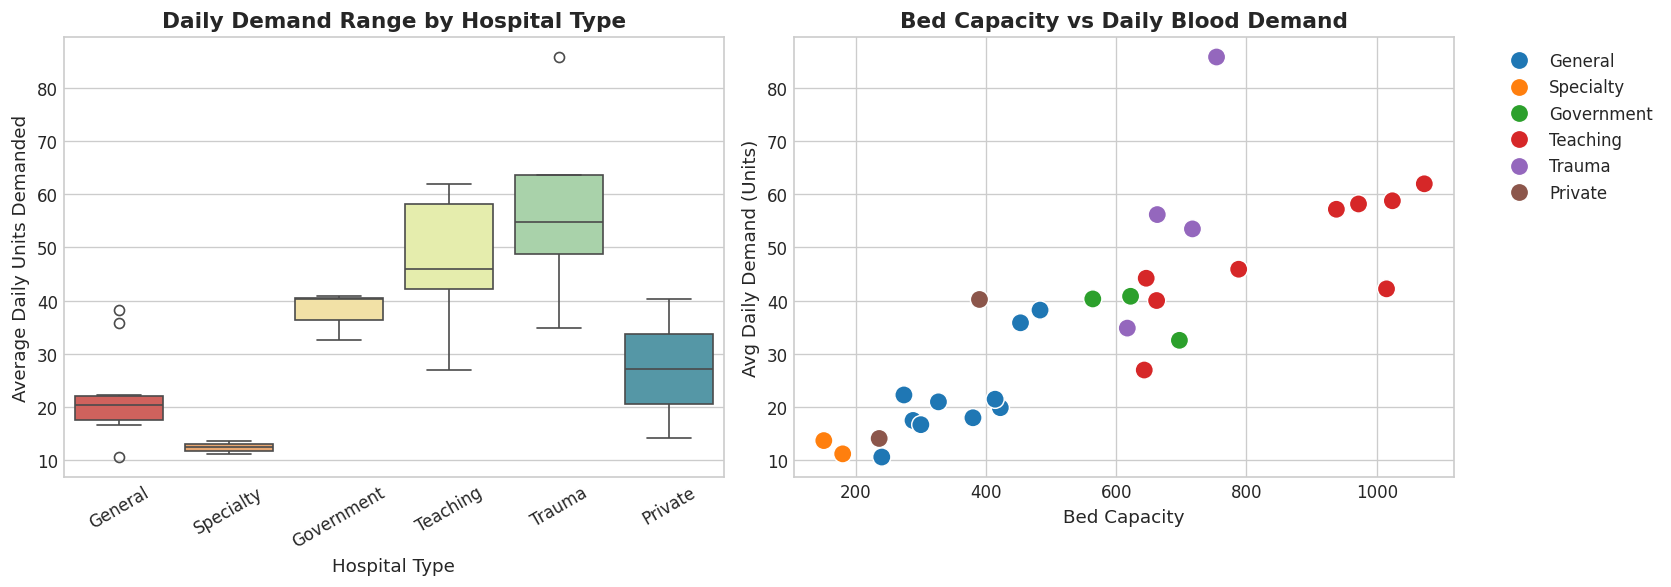

In [4]:
hosp_demand_summary = demand_df.groupby('hospital_id')['units_used'].sum().reset_index()
hosp_merged = hosp_demand_summary.merge(hospitals_df, on='hospital_id')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=hosp_merged, x='hospital_type', y='avg_daily_demand', ax=ax1, palette='Spectral')
ax1.set_title('Daily Demand Range by Hospital Type', fontsize=13, fontweight='bold')
ax1.set_xlabel('Hospital Type', fontsize=11)
ax1.set_ylabel('Average Daily Units Demanded', fontsize=11)
ax1.tick_params(axis='x', rotation=30)

sns.scatterplot(data=hosp_merged, x='bed_capacity', y='avg_daily_demand', hue='hospital_type', s=120, ax=ax2, palette='tab10')
ax2.set_title('Bed Capacity vs Daily Blood Demand', fontsize=13, fontweight='bold')
ax2.set_xlabel('Bed Capacity', fontsize=11)
ax2.set_ylabel('Avg Daily Demand (Units)', fontsize=11)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## 3. Historical Daily Blood Demand Over Time (2 Years)
Visualizing 730 days of simulated demand.
Key temporal dynamics:
1. **Monsoon Surges (July-September)**: Vector-borne illness (dengue/malaria) creating medical transfusion spikes.
2. **Weekend/Weekday Fluctuations**: Scheduled surgeries drop on weekends, while trauma incidents surge on Friday/Saturday nights.
3. **Festival Outliers**: Seasonal peaks during major celebrations.


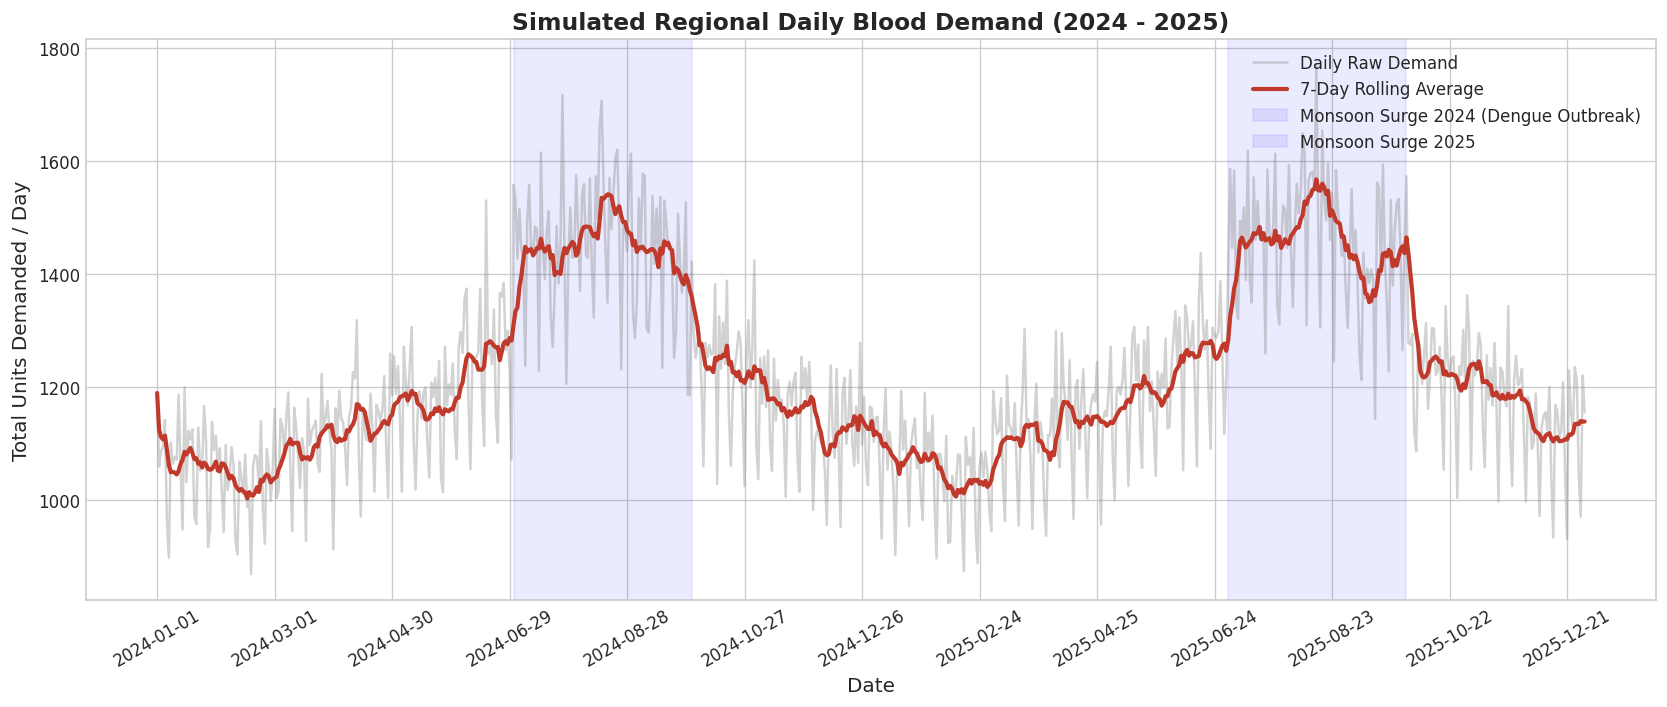

In [5]:
daily_total = demand_df.groupby('date')[['units_used', 'scheduled_surgery_units', 'trauma_units', 'emergency_units_used']].sum()
daily_total['rolling_7d'] = daily_total['units_used'].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_total.index, daily_total['units_used'], alpha=0.35, color='gray', label='Daily Raw Demand')
ax.plot(daily_total.index, daily_total['rolling_7d'], color='#c0392b', linewidth=2.5, label='7-Day Rolling Average')

# Annotate seasonal surge
ax.axvspan('2024-07-01', '2024-09-30', color='blue', alpha=0.08, label='Monsoon Surge 2024 (Dengue Outbreak)')
ax.axvspan('2025-07-01', '2025-09-30', color='blue', alpha=0.08, label='Monsoon Surge 2025')

# Set periodic ticks
ticks = [daily_total.index[i] for i in range(0, len(daily_total), 60)]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=30)
ax.set_title('Simulated Regional Daily Blood Demand (2024 - 2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Units Demanded / Day', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 4. Blood Inventory Dynamics & Batch Lifecycle
Cold-chain inventory evolves dynamically through collections, FEFO consumption, transfers, and expirations.


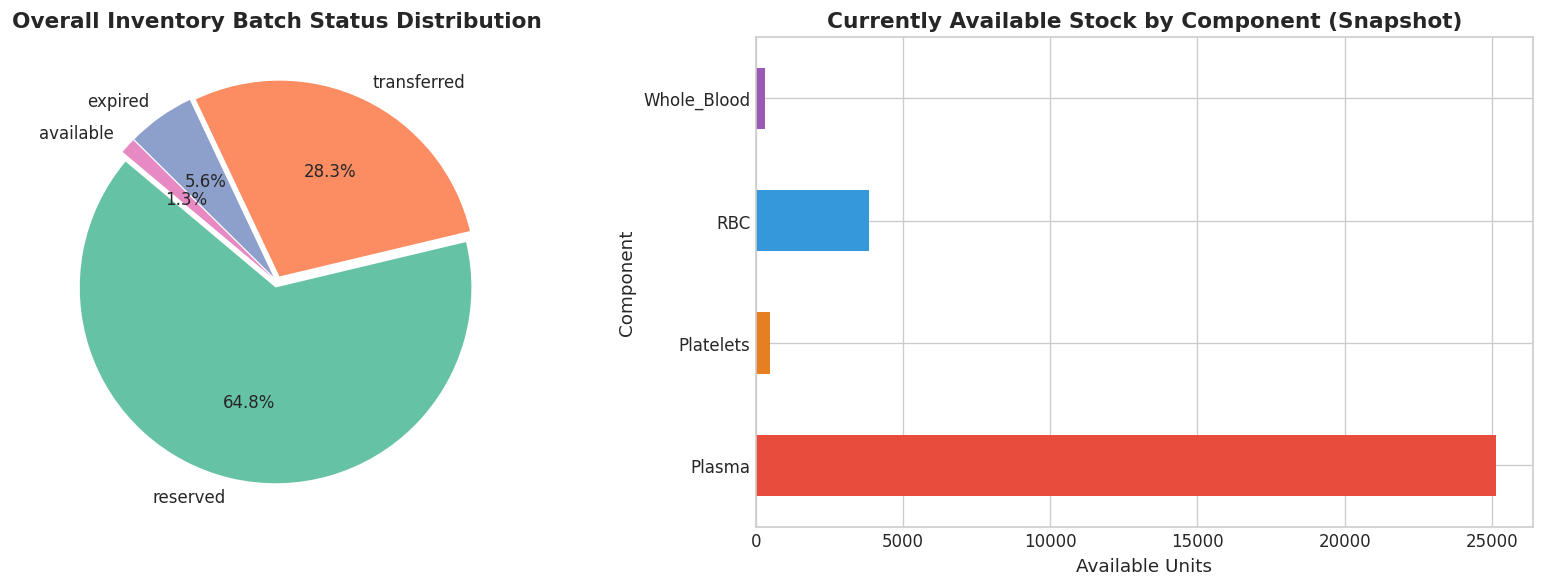

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

status_counts = inventory_df['status'].value_counts()
colors = sns.color_palette('Set2', len(status_counts))
explode = [0.03] * len(status_counts)
ax1.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=colors, startangle=140, explode=explode)
ax1.set_title('Overall Inventory Batch Status Distribution', fontsize=13, fontweight='bold')

available_batches = inventory_df[inventory_df['status'] == 'available']
if len(available_batches) > 0:
    comp_units = available_batches.groupby('component')['units'].sum()
    comp_units.plot(kind='barh', ax=ax2, color=['#e74c3c', '#e67e22', '#3498db', '#9b59b6'][:len(comp_units)])
    ax2.set_title('Currently Available Stock by Component (Snapshot)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Available Units', fontsize=11)
else:
    comp_units = inventory_df.groupby('component')['units'].sum()
    comp_units.plot(kind='barh', ax=ax2, color=['#e74c3c', '#e67e22', '#3498db', '#9b59b6'][:len(comp_units)])
    ax2.set_title('Total Batch Units by Component (Cumulative)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Total Units', fontsize=11)
ax2.set_ylabel('Component', fontsize=11)

plt.tight_layout()
plt.show()


## 5. Shortage & Fulfillment Analysis
A realistic healthcare simulation must not be frictionless.
Shortages occur during sudden mass emergencies, route disruptions, or depleted regional reserves of rare blood groups ($O^-, AB^-$).


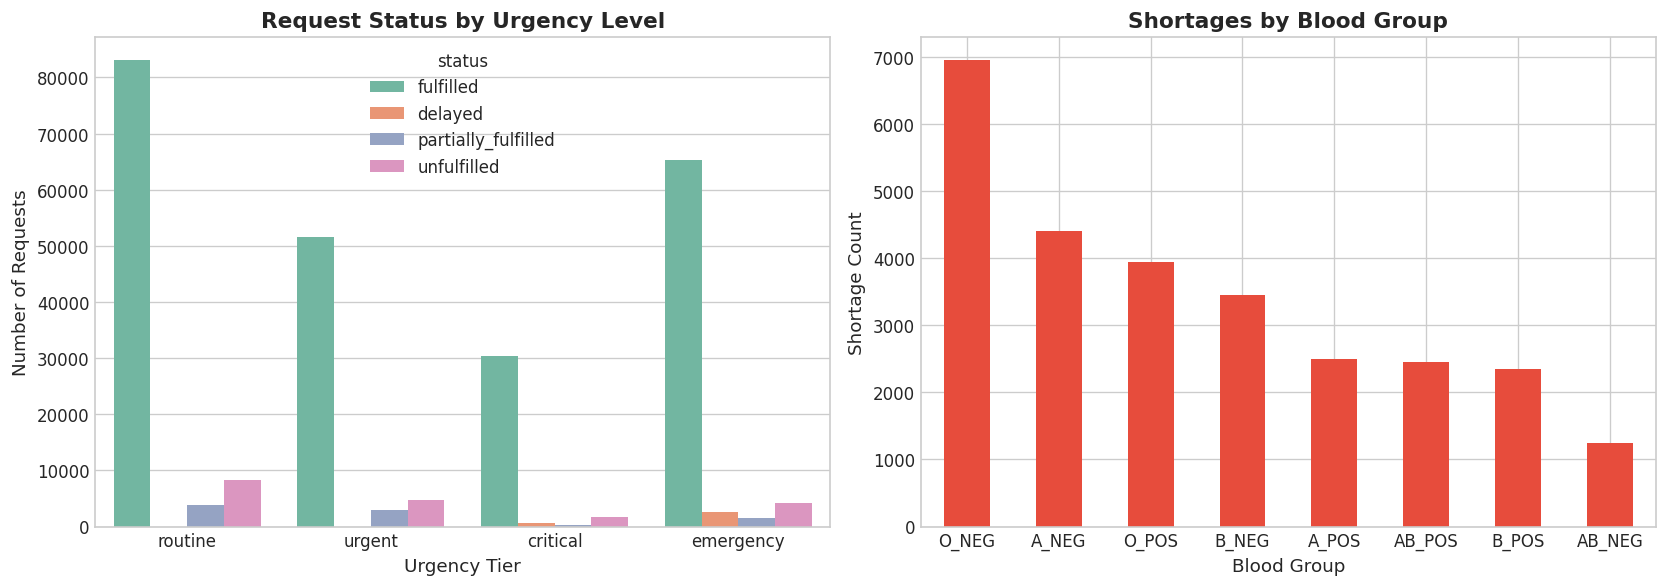

In [7]:
req_status_counts = requests_df['status'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=requests_df, x='urgency', hue='status', ax=ax1, palette='Set2')
ax1.set_title('Request Status by Urgency Level', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Requests', fontsize=11)
ax1.set_xlabel('Urgency Tier', fontsize=11)

shortage_bg = requests_df[requests_df['status'].isin(['unfulfilled', 'partially_fulfilled'])]['blood_group'].value_counts()
shortage_bg.plot(kind='bar', ax=ax2, color='#e74c3c')
ax2.set_title('Shortages by Blood Group', fontsize=13, fontweight='bold')
ax2.set_ylabel('Shortage Count', fontsize=11)
ax2.set_xlabel('Blood Group', fontsize=11)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


## 6. Emergency Incidents & Impact Analysis
Analyzing the 390 simulated emergency events (mass casualties, road accidents, facility failures, and transit disruptions).


C:\Users\bhanu\AppData\Local\Temp\ipykernel_27996\3193875009.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=emergency_df, y='event_type', order=emergency_df['event_type'].value_counts().index, ax=ax1, palette='mako')


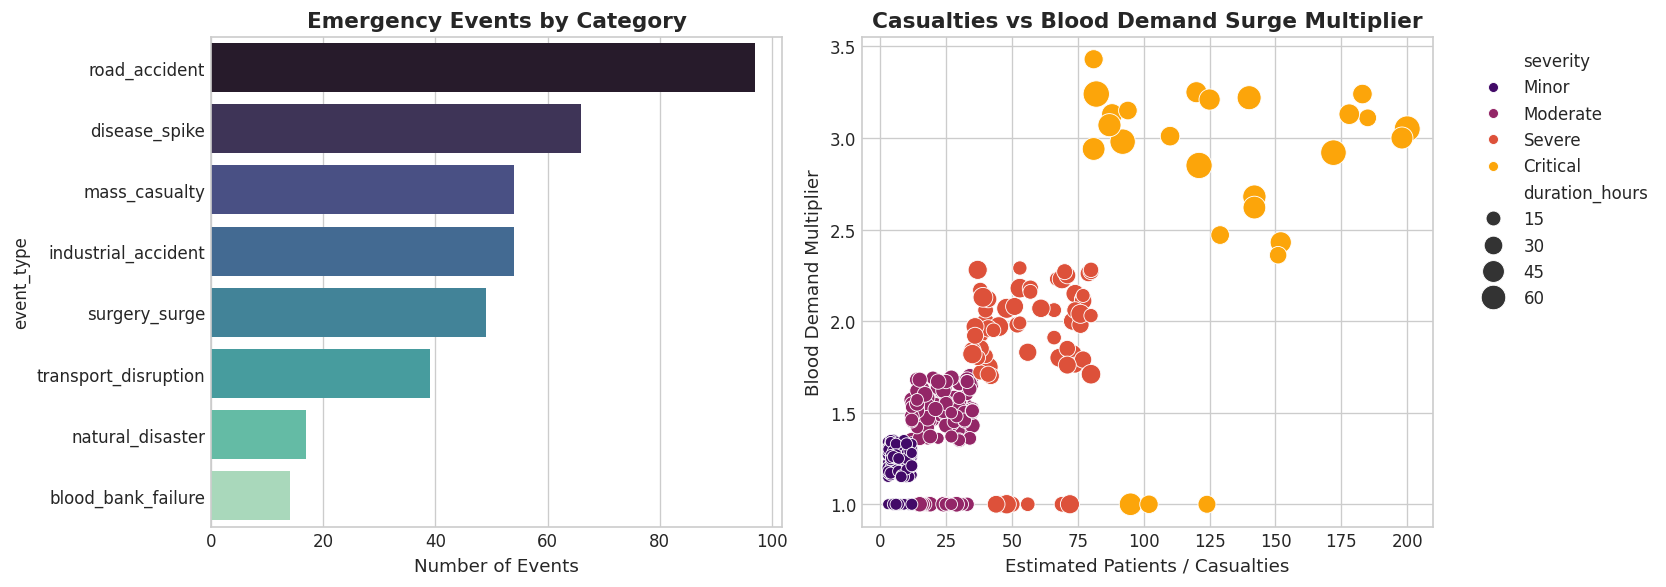

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=emergency_df, y='event_type', order=emergency_df['event_type'].value_counts().index, ax=ax1, palette='mako')
ax1.set_title('Emergency Events by Category', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Events', fontsize=11)

sns.scatterplot(data=emergency_df, x='estimated_patients', y='blood_demand_multiplier', hue='severity', size='duration_hours', sizes=(40, 250), ax=ax2, palette='inferno')
ax2.set_title('Casualties vs Blood Demand Surge Multiplier', fontsize=13, fontweight='bold')
ax2.set_xlabel('Estimated Patients / Casualties', fontsize=11)
ax2.set_ylabel('Blood Demand Multiplier', fontsize=11)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## 7. Blood Expiry Patterns by Component
Because blood components have drastically different clinical shelf lives (Platelets: 5 days vs RBC: 42 days vs Plasma: 365 days), wastage patterns diverge sharply.
Platelet management is the primary challenge in real-world blood banking due to rapid expiration.


C:\Users\bhanu\AppData\Local\Temp\ipykernel_27996\2600664888.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp_by_comp, x='component', y='units', ax=ax, palette='copper')


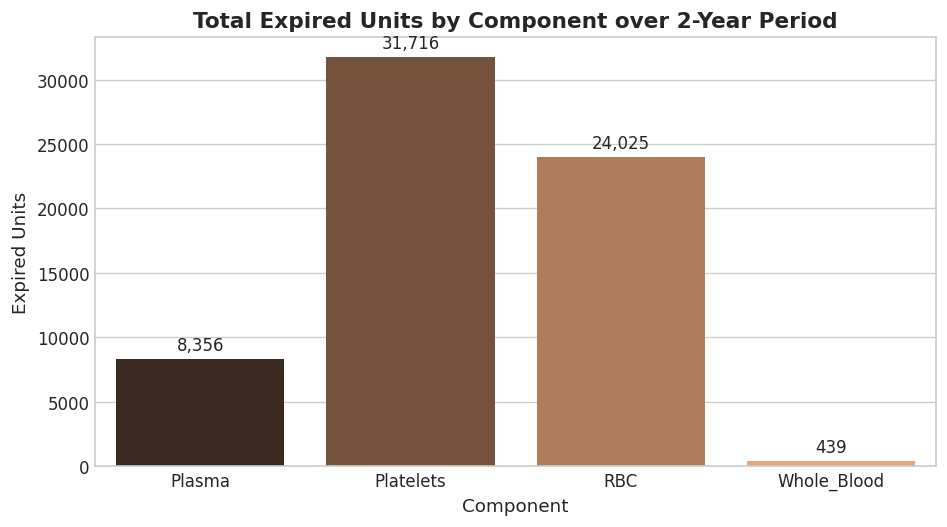

In [9]:
exp_df = inventory_df[inventory_df['status'] == 'expired']
exp_by_comp = exp_df.groupby('component')['units'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=exp_by_comp, x='component', y='units', ax=ax, palette='copper')
ax.set_title('Total Expired Units by Component over 2-Year Period', fontsize=13, fontweight='bold')
ax.set_ylabel('Expired Units', fontsize=11)
ax.set_xlabel('Component', fontsize=11)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


## 8. Geographic Distribution of Facilities (Metro Metropolis)
Spatial map showing the clustering of hospitals and blood banks across the metropolitan grid.
Tertiary Trauma and Teaching facilities anchor central high-density corridors, with District Blood Centers positioned across residential sectors.


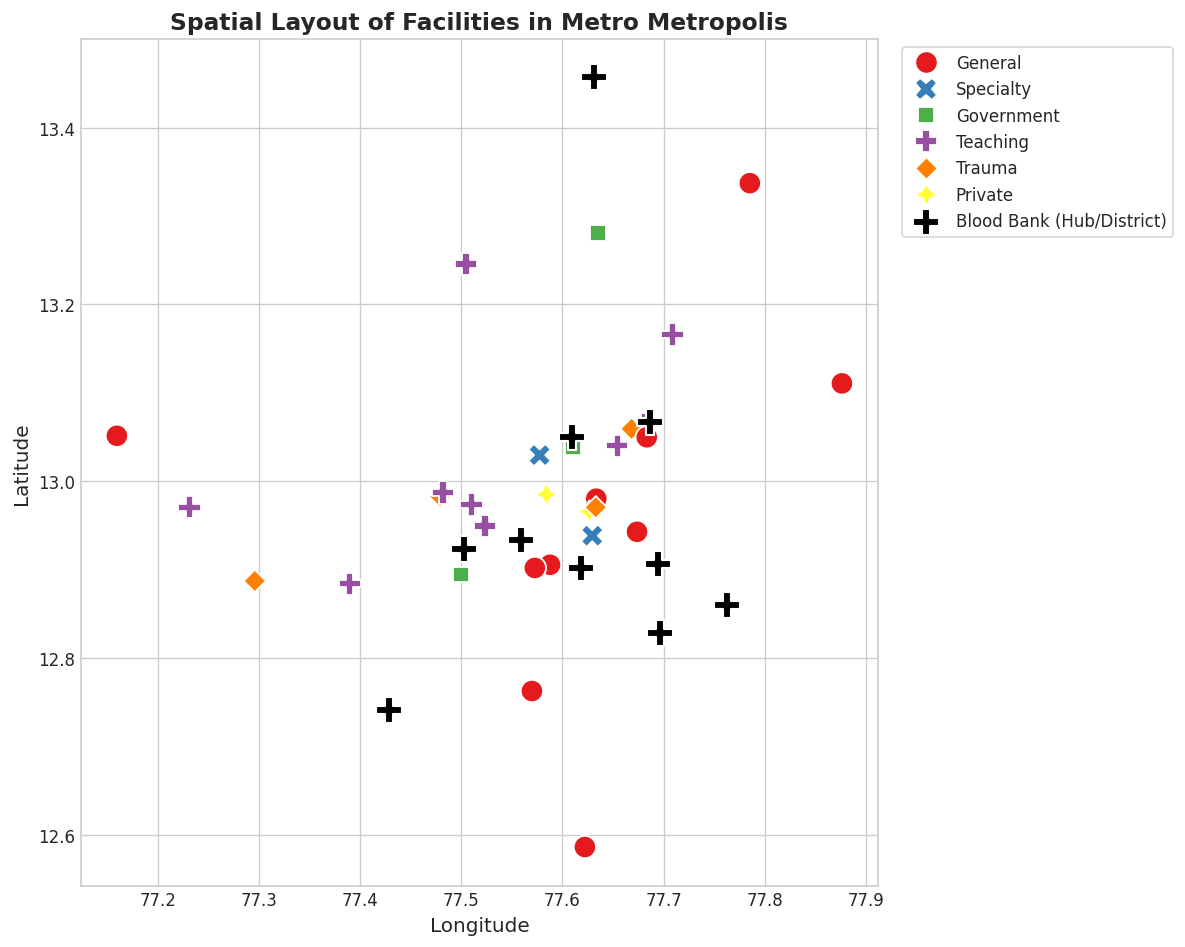

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot hospitals by type
sns.scatterplot(
    data=hospitals_df,
    x='longitude', y='latitude',
    hue='hospital_type',
    style='hospital_type',
    s=180,
    ax=ax,
    palette='Set1'
)

# Plot blood banks
sns.scatterplot(
    data=blood_banks_df,
    x='longitude', y='latitude',
    color='black',
    marker='P',
    s=250,
    ax=ax,
    label='Blood Bank (Hub/District)'
)

ax.set_title('Spatial Layout of Facilities in Metro Metropolis', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


## 9. Transport Network Dynamics
The command center relies on this network to route emergency transfers between blood banks and hospitals.


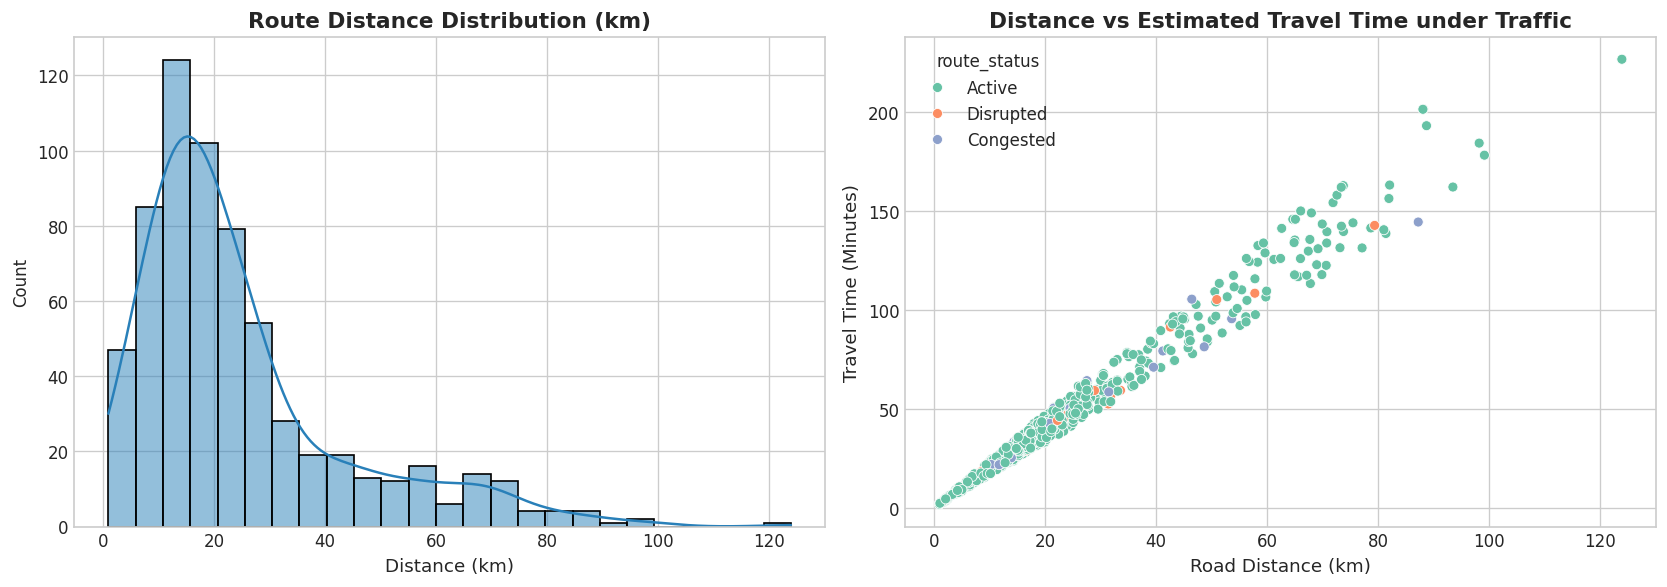

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(transport_df['distance_km'], bins=25, kde=True, ax=ax1, color='#2980b9')
ax1.set_title('Route Distance Distribution (km)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Distance (km)', fontsize=11)

sns.scatterplot(data=transport_df, x='distance_km', y='travel_time_minutes', hue='route_status', ax=ax2, palette='Set2')
ax2.set_title('Distance vs Estimated Travel Time under Traffic', fontsize=13, fontweight='bold')
ax2.set_xlabel('Road Distance (km)', fontsize=11)
ax2.set_ylabel('Travel Time (Minutes)', fontsize=11)

plt.tight_layout()
plt.show()


## 10. Demand Matrix: Blood Group vs Component
Comprehensive heatmap of clinical requisitions across components and blood groups.


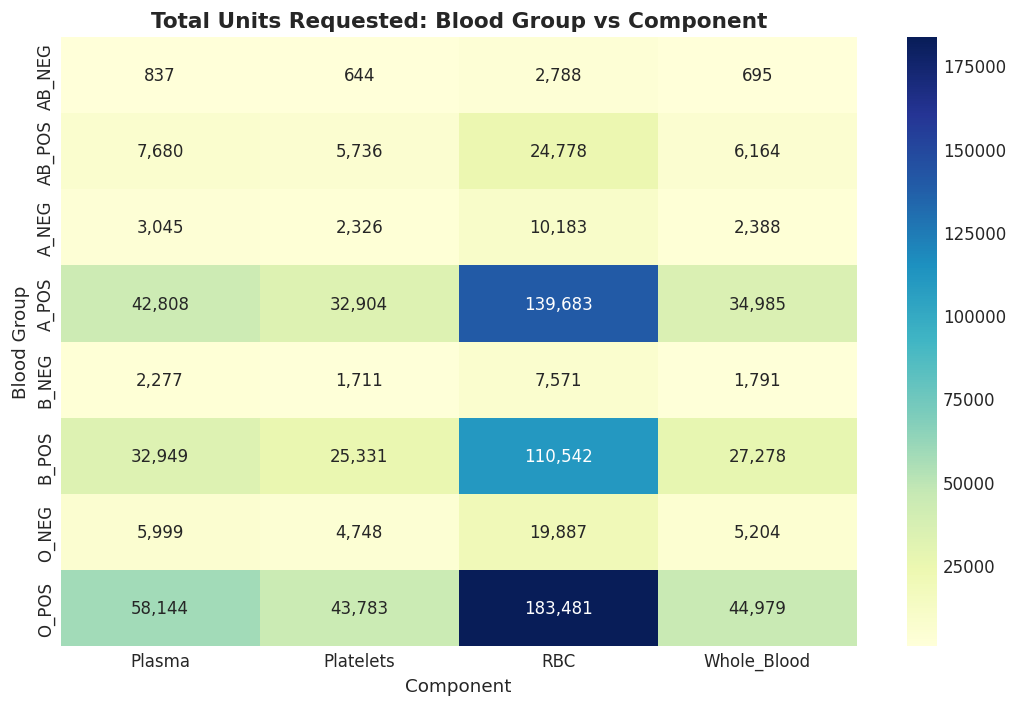

In [12]:
req_cross = pd.crosstab(requests_df['blood_group'], requests_df['component'], values=requests_df['units_required'], aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(req_cross, annot=True, fmt=',.0f', cmap='YlGnBu', cbar=True, ax=ax)
ax.set_title('Total Units Requested: Blood Group vs Component', fontsize=13, fontweight='bold')
ax.set_ylabel('Blood Group', fontsize=11)
ax.set_xlabel('Component', fontsize=11)
plt.tight_layout()
plt.show()


## 11. Machine Learning & Mathematical Optimization Roadmap

This synthetic dataset was architected specifically to support the 4 future intelligent subsystems of the **AI Blood Supply Command Center**:

```text
┌────────────────────────────────────────────────────────────────────────┐
│               AI BLOOD SUPPLY COMMAND CENTER PLATFORM                  │
└──────────────────────────────────┬─────────────────────────────────────┘
                                   │
       ┌───────────────────────────┼───────────────────────────┐
       ▼                           ▼                           ▼
┌──────────────┐            ┌──────────────┐            ┌──────────────┐
│ Model 1:     │            │ Model 2:     │            │ Model 3:     │
│ Demand       │            │ Shortage     │            │ Donor        │
│ Forecasting  │            │ Prediction   │            │ Ranking      │
│ (XGBoost)    │            │ (Classifier) │            │ (Matching)   │
└──────┬───────┘            └──────┬───────┘            └──────┬───────┘
       │                           │                           │
       └───────────────────────────┼───────────────────────────┘
                                   ▼
                   ┌───────────────────────────────┐
                   │ Engine 4: Network Optimization│
                   │ (Google OR-Tools / MILP)      │
                   └───────────────┬───────────────┘
                                   ▼
                   ┌───────────────────────────────┐
                   │ Automated Real-Time Dispatch  │
                   │ & Command Center Dashboard    │
                   └───────────────────────────────┘
```

1. **Model 1 — 24/48/72 Hour Demand Forecasting**:
   - Features: Hospital type, bed capacity, day-of-week, season, weather, holiday flag, festival, disease spike flag, historical lag demand (t-1, t-7).
   - Target: `units_used` by blood group and component.
   - Algorithms: XGBoost / LightGBM regressor.

2. **Model 2 — Shortage Risk Early Warning**:
   - Target: Binary flag (`will_hospital_shortage_occur_within_48h`).
   - Features: Current local available stock, scheduled surgeries, historical burn rate, route disruption status.

3. **Model 3 — Intelligent Donor Ranking & Dispatch**:
   - Compatible donor discovery filtering by `is_compatible(donor_bg, recipient_bg)`.
   - Scoring based on: distance to hospital, donor response probability, availability, days since last donation ($> 90$ days).

4. **Engine 4 — Mathematical Network Optimization (OR-Tools MILP)**:
   - Formulated as a Multi-Commodity Network Flow problem with perishability constraints.
   - Decides: Source blood bank $	o$ Destination hospital transfer quantity subject to transit time, cooler capacity, and shelf life.
